# Group 4: Fermentation Deviation Detection

**Sequence classification with GRU, LSTM and bidirectional layers**  
Synthetic teaching dataset. Session 9: Group Deep Learning Challenge.

<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-9/notebooks/04_group4_fermentation_gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

> **Colab workflow:** Save a copy in Drive, then choose Runtime > Run all. The required teaching dataset downloads automatically; Google Drive is not mounted.



## How to work
1. Run the baseline. 2. Change one main factor in Experiment 1. 3. Change one main factor in Experiment 2. 4. Record evidence for your five-slide presentation.

In [1]:
from pathlib import Path
import os, time, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, recall_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
keras.utils.set_random_seed(SEED)
# Portable workshop data setup: local Jupyter first, Colab fallback.
DATA_FILE = 'group4_fermentation_deviation.npz'
LOCAL_DATA_DIR = Path('../data')
if (LOCAL_DATA_DIR / DATA_FILE).exists():
    DATA_DIR = LOCAL_DATA_DIR
    IN_COLAB = False
else:
    from urllib.request import urlretrieve
    try:
        import google.colab  # type: ignore  # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False
    DATA_DIR = Path('/content/dl-food-research-data') if IN_COLAB else Path.cwd() / '.workshop-data'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    target = DATA_DIR / DATA_FILE
    if not target.exists():
        url = 'https://raw.githubusercontent.com/khairuladib94/dl-food-research/main' + '/session-9/data/' + DATA_FILE
        print(f'Downloading {DATA_FILE} ...')
        urlretrieve(url, target)
    print(f'Dataset ready: {target}')
FIG_DIR = Path('/content/dl-food-research-figures') if IN_COLAB else Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)


TensorFlow: 2.21.0 | Keras: 3.15.0


## 1. Load and explore sensor sequences

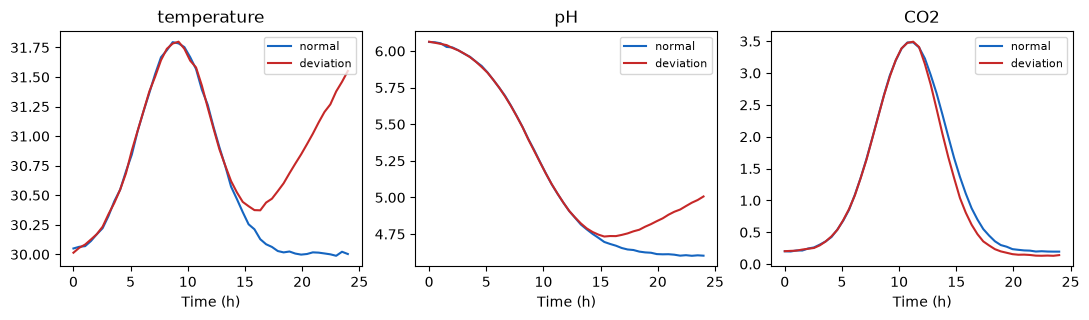

Shape: (480, 48, 3) | class counts: [240 240]


In [2]:
d=np.load(DATA_DIR/'group4_fermentation_deviation.npz')
X,y,t,names=d['sequences'],d['labels'],d['time_hours'],d['sensor_names']
fig,ax=plt.subplots(1,3,figsize=(11,3.3))
for cls,color in [(0,'#1565c0'),(1,'#c62828')]:
    mean=X[y==cls].mean(0)
    for j in range(3): ax[j].plot(t,mean[:,j],color=color,label='deviation' if cls else 'normal')
for j in range(3): ax[j].set(title=names[j],xlabel='Time (h)'); ax[j].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/'group4_eda.png',dpi=150); plt.show()
print('Shape:',X.shape,'| class counts:',np.bincount(y))

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,stratify=y,random_state=SEED)
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=.20,stratify=y_train,random_state=SEED)
mu=X_train.mean((0,1),keepdims=True); sd=X_train.std((0,1),keepdims=True)+1e-8
X_train,X_val,X_test=(X_train-mu)/sd,(X_val-mu)/sd,(X_test-mu)/sd

## 2. Baseline and two controlled experiments

In [4]:
def build_seq(input_shape,kind='GRU',units=8):
    inp=keras.layers.Input(input_shape)
    if kind=='GRU': x=keras.layers.GRU(units)(inp)
    elif kind=='LSTM': x=keras.layers.LSTM(units)(inp)
    else: x=keras.layers.Bidirectional(keras.layers.LSTM(units))(inp)
    x=keras.layers.Dense(12,activation='relu')(x); out=keras.layers.Dense(1,activation='sigmoid')(x)
    model=keras.Model(inp,out); model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    return model

def run(name,kind='GRU',units=8,window=48,epochs=12):
    keras.utils.set_random_seed(SEED)
    tr,va,te=X_train[:,:window],X_val[:,:window],X_test[:,:window]
    model=build_seq(tr.shape[1:],kind,units)
    hist=model.fit(tr,y_train,validation_data=(va,y_val),epochs=epochs,batch_size=32,verbose=0)
    pred=(model.predict(te,verbose=0).ravel()>=.5).astype(int)
    return model,hist,pred,{'run':name,'accuracy':accuracy_score(y_test,pred),'recall':recall_score(y_test,pred),'F1':f1_score(y_test,pred)}

baseline=run('Baseline: GRU-8, 20 steps','GRU',8,window=20,epochs=6)
exp1=run('Exp 1: GRU-24, 48 steps','GRU',24,window=48)
exp2=run('Exp 2: BiLSTM-16, 48 steps','BiLSTM',16,window=48)
results=pd.DataFrame([baseline[3],exp1[3],exp2[3]])
display(results.round(3))

,run,accuracy,recall,F1
0,"Baseline: GRU-8, 20 steps",0.469,0.792,0.598
1,"Exp 1: GRU-24, 48 steps",1.000,1.000,1.000
2,"Exp 2: BiLSTM-16, 48 steps",1.000,1.000,1.000


### YOUR TASK
Compare recurrent capacity and architecture. Explain why recall matters for process deviations.

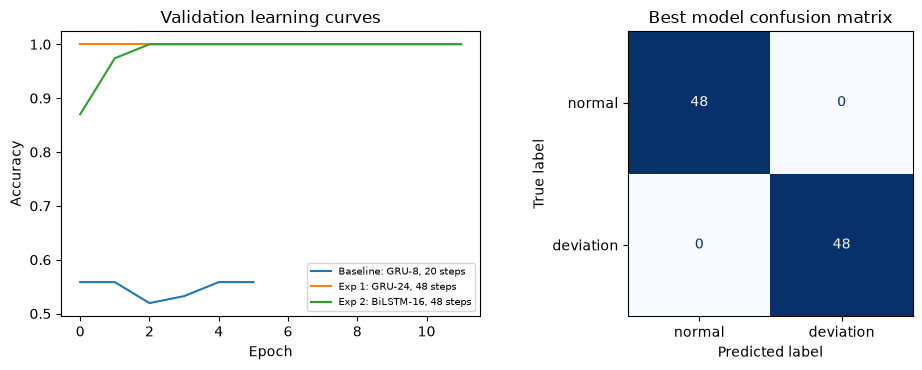

Presentation-ready summary: {'run': 'Exp 1: GRU-24, 48 steps', 'accuracy': 1.0, 'recall': 1.0, 'F1': 1.0}


In [5]:
best=max([baseline,exp1,exp2],key=lambda r:r[3]['F1'])
fig,ax=plt.subplots(1,2,figsize=(10,3.8))
for r in [baseline,exp1,exp2]: ax[0].plot(r[1].history['val_accuracy'],label=r[3]['run'])
ax[0].set(title='Validation learning curves',xlabel='Epoch',ylabel='Accuracy'); ax[0].legend(fontsize=7)
ConfusionMatrixDisplay(confusion_matrix(y_test,best[2]),display_labels=['normal','deviation']).plot(ax=ax[1],cmap='Blues',colorbar=False)
ax[1].set_title('Best model confusion matrix')
plt.tight_layout(); plt.savefig(FIG_DIR/'group4_results.png',dpi=150); plt.show()
print('Presentation-ready summary:',best[3])